<a href="https://colab.research.google.com/github/srishti-bs/Statistical-Foundations-of-Data-Science/blob/main/patient_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Count: 6000
+---+------+---+-----------+-------+-------+
|age|gender|bp |cholesterol|glucose|outcome|
+---+------+---+-----------+-------+-------+
|45 |1     |130|220        |110    |1      |
|50 |0     |120|180        |95     |0      |
|65 |1     |140|250        |140    |1      |
|30 |0     |110|160        |90     |0      |
|55 |1     |135|230        |125    |1      |
|40 |0     |118|175        |100    |0      |
|45 |1     |130|220        |110    |1      |
|50 |0     |120|180        |95     |0      |
|65 |1     |140|250        |140    |1      |
|30 |0     |110|160        |90     |0      |
+---+------+---+-----------+-------+-------+
only showing top 10 rows


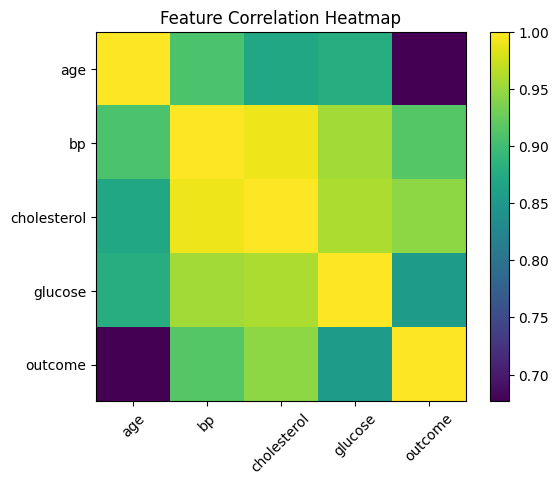

Area Under ROC: 1.0


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import matplotlib.pyplot as plt

# Step 1: Initialize Spark Session
spark = SparkSession.builder \
.appName("PatientOutcomePrediction") \
.getOrCreate()

# Step 2: Create synthetic big healthcare dataset
data = spark.createDataFrame([
(45, 1, 130, 220, 110, 1),
(50, 0, 120, 180, 95, 0),
(65, 1, 140, 250, 140, 1),
(30, 0, 110, 160, 90, 0),
(55, 1, 135, 230, 125, 1),
(40, 0, 118, 175, 100, 0)
] * 1000, # simulate large dataset
["age", "gender", "bp", "cholesterol", "glucose", "outcome"])
print("Dataset Count:", data.count())
data.show(10, truncate=False)

# Step 3: Feature Vectorization
assembler = VectorAssembler(
inputCols=["age", "gender", "bp", "cholesterol", "glucose"], outputCol="features"
)
data_assembled = assembler.transform(data)

# Step 4: Feature Scaling
scaler = StandardScaler( inputCol="features", outputCol="scaled_features", withMean=True, withStd=True
)
scaler_model = scaler.fit(data_assembled)
data_scaled = scaler_model.transform(data_assembled)

# Additional Step: Feature Correlation Heatmap
import numpy as np
pdf = data.toPandas()

# Convert PySpark DataFrame to Pandas DataFrame
corr = pdf[['age','bp','cholesterol','glucose','outcome']].corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.show()

# Step 5: Train-Test Split
train_data, test_data = data_scaled.randomSplit([0.7, 0.3], seed=42)

# Step 6: Logistic Regression Model
lr = LogisticRegression(
featuresCol="scaled_features", labelCol="outcome"
)
model = lr.fit(train_data)

# Step 7: Predictions
predictions = model.transform(test_data)

# Step 8: Model Evaluation
evaluator = BinaryClassificationEvaluator( labelCol="outcome", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)
print("Area Under ROC:", auc)

# Stop Spark session
spark.stop()

